In [1]:
import pandas as pd

rfm = pd.read_csv(
    'RFM_Customer_Segmentation.csv'
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,00082cbe03e478190aadbea78542e933,305,1,79.00,2,1,3,213,Need Attention
1,00191a9719ef48ebb5860b130347bf33,520,1,47.90,1,1,3,113,Need Attention
2,0019e8c501c85848ac0966d45226fa1d,143,1,159.99,4,1,5,415,Need Attention
3,0023557a94bef0038066b5d1b3dc763e,176,1,0.00,4,1,1,411,Need Attention
4,0032ca69771a7758ce643258bb9e4ac7,66,1,45.00,5,1,2,512,Need Attention


**select Featured for  clustering**

In [2]:
features = rfm[
    ['Recency',
     'Frequency',
     'Monetary']
]

**Standardize Features**

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

**Elbow Method**

In [4]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(
        scaled_features
    )

    wcss.append(
        kmeans.inertia_
    )

**Plot Elbow curve**

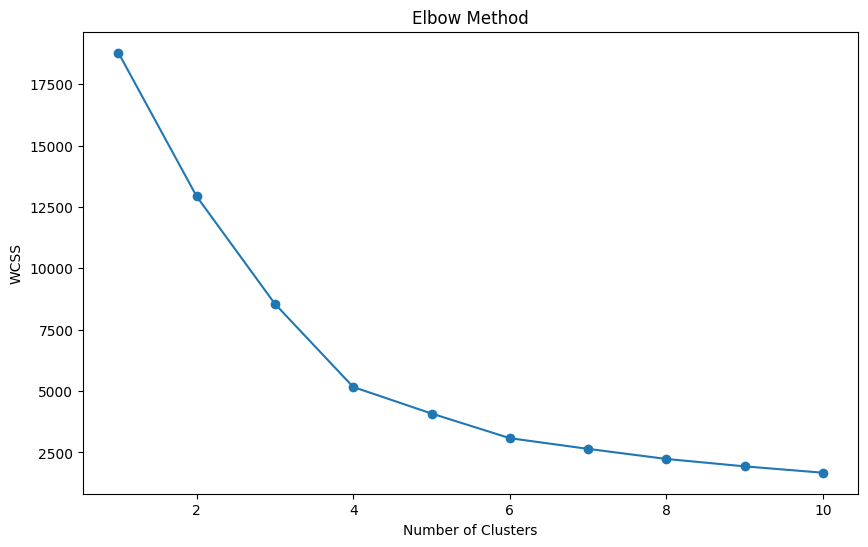

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title(
    'Elbow Method'
)

plt.xlabel(
    'Number of Clusters'
)

plt.ylabel(
    'WCSS'
)

plt.show()

**create clusters**

In [6]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = (
    kmeans.fit_predict(
        scaled_features
    )
)

**cluster Summary**

In [7]:
cluster_summary = (
    rfm.groupby('Cluster')
    .agg(
        Customers=('CustomerID','count'),
        Avg_Recency=('Recency','mean'),
        Avg_Frequency=('Frequency','mean'),
        Avg_Monetary=('Monetary','mean')
    )
)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3381,149.708962,1.000000,77.225593
1,2523,413.868807,1.000000,76.841554
2,11,244.090909,2.090909,125.534545
3,312,259.330128,1.000000,557.927756
4,36,174.333333,1.000000,1897.988056


**RFM Segments vs clusters**

In [8]:
cluster_vs_segment = pd.crosstab(
    rfm['Cluster'],
    rfm['Segment']
)

cluster_vs_segment

Segment,At Risk,Champions,Lost Customers,Loyal Customers,Need Attention,Potential Loyalists
Cluster,,,,,,
0,0,362,0,1007,1081,931
1,1402,0,393,64,664,0
2,4,5,0,2,0,0
3,81,53,0,24,111,43
4,5,9,0,1,14,7


**cluster visualization**

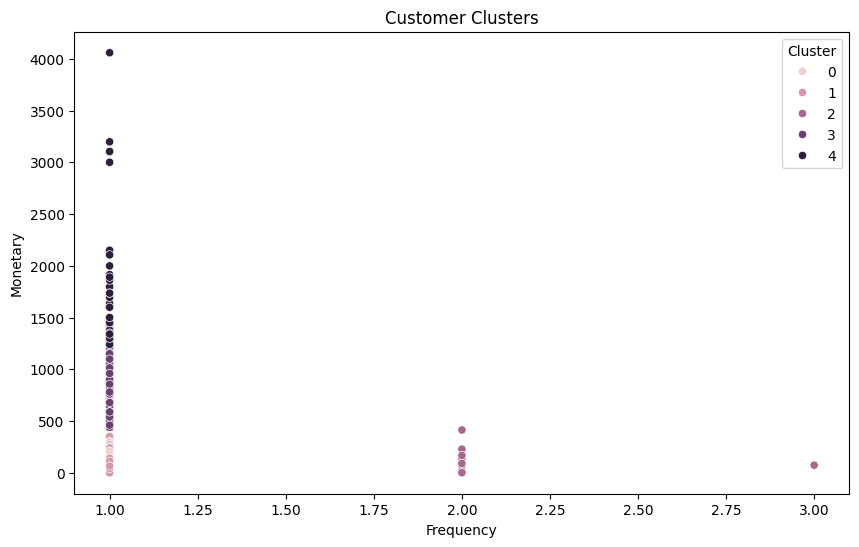

In [9]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster'
)

plt.title(
    'Customer Clusters'
)

plt.show()